# Stock market trend prediction

### This project focuses on analyzing Tesla’s stock price time series to detect and forecast market trends (bullish, bearish, or neutral). It begins with traditional statistical and technical indicator methods, then progressively integrates advanced machine learning and deep learning algorithms to improve the accuracy and responsiveness of trend detection. The outcome is a comparative study and prototype capable of automatically identifying the current trend and predicting potential reversals.

By Thomas Jin, Thibault Gauthé, Yijia Zhang

In [4]:
!pip install ta

import pandas as pd
import ta
import seaborn as sns
import numpy as np
from math import ceil
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Data Collection

In [5]:
data = pd.read_csv('Tesla_stock_data.csv')
data.head()

,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


### Data Overview

In [6]:
print("Shape:", data.shape)

Shape: (3843, 6)


In [7]:
print("\nColumns and dtypes:\n", data.dtypes)


Columns and dtypes:
 Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [8]:
print("\nFirst 5 rows:")
print(data.head())
print("\nLast 5 rows:")
print(data.tail())


First 5 rows:
         Date     Close      High       Low      Open     Volume
0  2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
1  2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2  2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
3  2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
4  2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500

Last 5 rows:
            Date       Close        High         Low        Open     Volume
3838  2025-10-01  459.459991  462.290009  440.750000  443.799988   98122300
3839  2025-10-02  436.000000  470.750000  435.570007  470.540009  137009000
3840  2025-10-03  429.829987  446.769989  416.579987  443.290009  133188200
3841  2025-10-06  453.250000  453.549988  436.690002  440.750000   85324900
3842  2025-10-07  433.089996  452.679993  432.450012  447.820007  101798300


In [9]:
print("\nMissing values (count):\n", data.isnull().sum())


Missing values (count):
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
print("\nDescriptive statistics:\n", data.describe().T)


Descriptive statistics:
          count          mean           std           min           25%  \
Close   3843.0  9.388797e+01  1.186940e+02  1.053333e+00  1.269167e+01   
High    3843.0  9.599240e+01  1.214350e+02  1.108667e+00  1.288867e+01   
Low     3843.0  9.168992e+01  1.158776e+02  9.986670e-01  1.240900e+01   
Open    3843.0  9.391116e+01  1.187844e+02  1.076000e+00  1.261367e+01   
Volume  3843.0  9.699445e+07  7.621392e+07  1.777500e+06  5.086650e+07   

                 50%           75%           max  
Close   1.945400e+01  2.007400e+02  4.798600e+02  
High    1.988800e+01  2.045917e+02  4.885400e+02  
Low     1.911600e+01  1.952133e+02  4.575100e+02  
Open    1.948333e+01  2.004667e+02  4.759000e+02  
Volume  8.339850e+07  1.222820e+08  9.140820e+08  


We can see that the brut dataset has no missing values nor duplicates so at this point we don't have nothing to clean

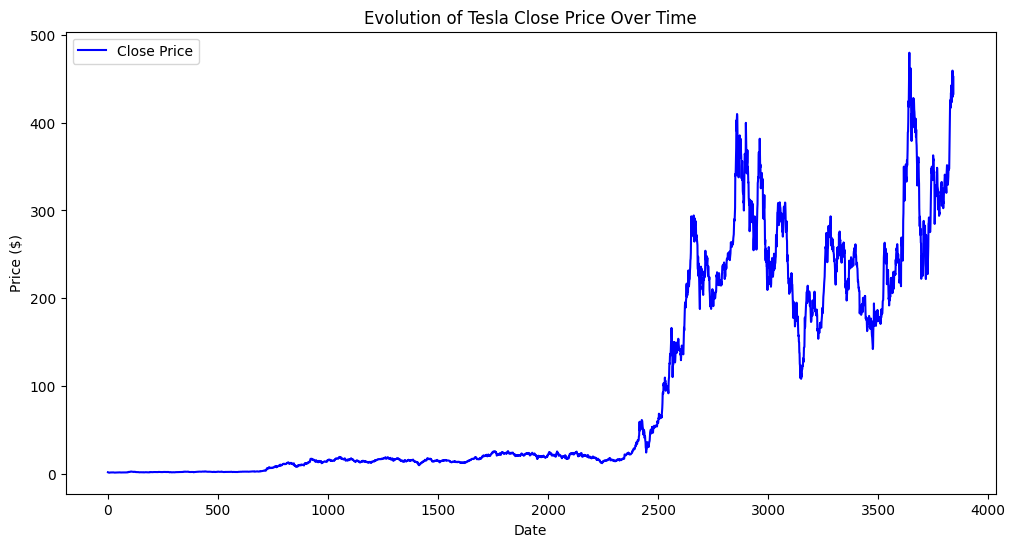

In [12]:
plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Close Price", color="blue")
plt.title("Evolution of Tesla Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

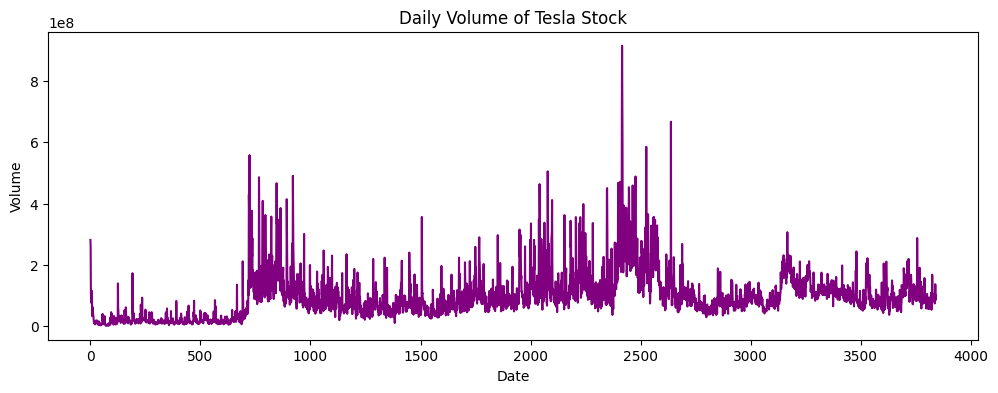

In [13]:
plt.figure(figsize=(12,4))
plt.plot(data["Volume"], color="purple")
plt.title("Daily Volume of Tesla Stock")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# Data Preparation for EDA

### Coherence verification

In [14]:
data = data.sort_index() # Sort the data by index to ensure chronological order
print(data.index.is_monotonic_increasing) # Verify that the index is sorted in increasing order (should return True)

True


In [15]:
# Check for rows where High is less than Low

invalid = data[data["High"] < data["Low"]]
print(invalid.head())

Empty DataFrame
Columns: [Date, Close, High, Low, Open, Volume]
Index: []


In [16]:
# Check for invalid values in Volume column

print((data["Volume"] <= 0).sum())

0


In [17]:
# Check for extreme daily returns (e.g., greater than 50% in absolute value)
data["Return_1d"] = data["Close"].pct_change()
print((data["Return_1d"].abs() > 0.5).sum())

0


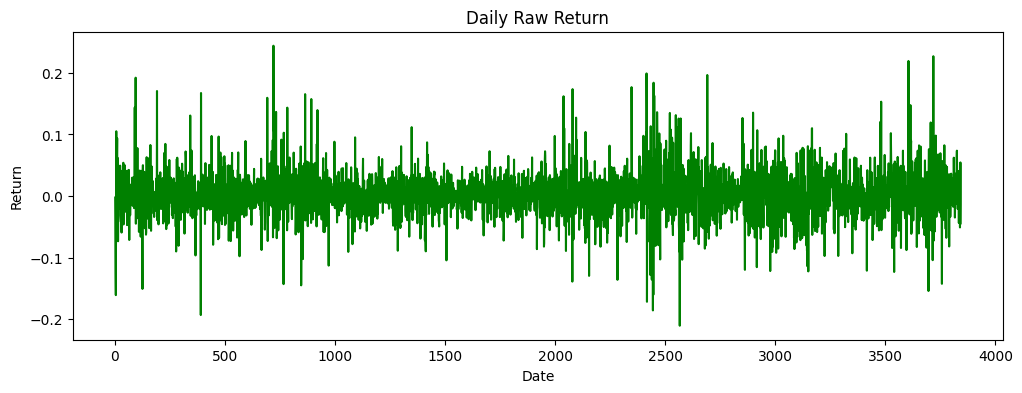

In [18]:
plt.figure(figsize=(12,4))
plt.plot(data["Return_1d"], color="green")
plt.title("Daily Raw Return")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

### Analysis of Daily Returns

The daily return plot shows the volatility and price fluctuations of Tesla stock over time. We observe several key patterns:

- **High volatility periods**: There are notable spikes in both positive and negative returns, indicating periods of significant market movements
- **Volatility clustering**: Periods of high volatility tend to cluster together, which is typical for stock market data
- **Extreme events**: Some returns exceed ±20%, suggesting major announcements or market events affecting Tesla's stock price
- **Recent patterns**: The more recent data (right side of the plot) shows continued volatility, reflecting Tesla's dynamic market behavior

This return series will be essential for our trend prediction models, as it captures the momentum and volatility characteristics that often precede trend changes.

### Feature engineering

In [19]:
# Let's convert the 'Date' column to datetime format and set it as the index
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')
data = data.sort_values('Date')
data = data.set_index('Date')

In [20]:
# Here we will create new features that could help our model to predict trends better

# moving averages : the meaning of the closing prices over a specific period
data["MA50"] = data["Close"].rolling(50).mean()
data["MA200"] = data["Close"].rolling(200).mean()

# rolling volatility : it measures the price fluctuations over a specific period
data["Volatility_20d"] = data["Return_1d"].rolling(20).std()

# Relative Strength Index (RSI) : it indicates whether a stock is overbought or oversold
data["RSI_14"] = ta.momentum.rsi(data["Close"], window=14)

In [21]:
# Now, we will create the target variable 'Trend' by comparing the closing price of the next day with the current day

data["Trend"] = (data["Close"].shift(-1) > data["Close"]).astype(int) # 1 if bullish day, 0 if bearish day

In [22]:
print(data.head())

               Close      High       Low      Open     Volume  Return_1d  \
Date                                                                       
2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500        NaN   
2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500  -0.002511   
2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000  -0.078473   
2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000  -0.125683   
2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500  -0.160937   

            MA50  MA200  Volatility_20d  RSI_14  Trend  
Date                                                    
2010-06-29   NaN    NaN             NaN     NaN      0  
2010-06-30   NaN    NaN             NaN     NaN      0  
2010-07-01   NaN    NaN             NaN     NaN      0  
2010-07-02   NaN    NaN             NaN     NaN      0  
2010-07-06   NaN    NaN             NaN     NaN      0  


We can see here that some value are missing because in order to get those you have to get the values of the 50/200 previous one

### Final cleaning step

In [23]:
data = data.dropna()
print(data.isnull().sum())

Close             0
High              0
Low               0
Open              0
Volume            0
Return_1d         0
MA50              0
MA200             0
Volatility_20d    0
RSI_14            0
Trend             0
dtype: int64


In [24]:
print(data.head())
print(data.tail())

               Close      High       Low      Open    Volume  Return_1d  \
Date                                                                      
2011-04-12  1.643333  1.680667  1.620000  1.672000  20361000  -0.024535   
2011-04-13  1.662000  1.712667  1.654000  1.675333  18172500   0.011359   
2011-04-14  1.676000  1.685333  1.613333  1.658000  14751000   0.008424   
2011-04-15  1.705333  1.745333  1.694000  1.710000  14152500   0.017502   
2011-04-18  1.668667  1.708000  1.624000  1.675333  15508500  -0.021501   

                MA50     MA200  Volatility_20d     RSI_14  Trend  
Date                                                              
2011-04-12  1.597293  1.581757        0.045385  49.263004      1  
2011-04-13  1.598653  1.582103        0.045344  50.769372      1  
2011-04-14  1.600253  1.582540        0.045328  51.922269      1  
2011-04-15  1.602853  1.583747        0.045404  54.335217      0  
2011-04-18  1.604947  1.585690        0.045693  50.896591      1  
     

# EDA Phase

# Data preparation for modeling

### Train Test Split

Before normalizing for base models like logistic regression, we will split the dataset into two parts: the training set and the test set. We will not shuffle the data because we are working with time series data, where the chronological order must be preserved to avoid data leakage and ensure realistic model evaluation.

In [25]:
features = ["Return_1d", "MA50", "MA200", "Volatility_20d", "RSI_14"]
target = "Trend"

In [26]:
# in order to avoid data leakage, we will split the data into training and testing sets based on a specific date
# and not by using the train_test_split function because it shuffles the data by default
# We will use data up to 2022-12-31 for training and data from 2023-01-01 for testing (80-20 split)
train = data.loc[: "2022-12-31"]
test = data.loc["2023-01-01":]

In [27]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [28]:
# Verify that there is no overlap between training and testing sets
print(X_train.shape, X_test.shape)
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

assert train.index.max() < test.index.min()

(2951, 5) (693, 5)
2011-04-12 00:00:00 2022-12-30 00:00:00
2023-01-03 00:00:00 2025-10-07 00:00:00


The 80-20 temporal split (training on data up to 2022-12-31 and testing from 2023-01-01 onward) is strategically chosen to replicate a realistic trading scenario. The model learns from Tesla's long historical patterns spanning over a decade, then faces the challenge of predicting trends in the highly volatile 2023-2025 period characterized by post-COVID market dynamics, interest rate changes, and increased uncertainty. This approach provides the most rigorous test of model robustness, as it must generalize to recent market conditions that differ significantly from the training period, mimicking how a production model would perform when deployed in live trading environments.

### Normalization and scaling

In [29]:
scaler = StandardScaler()

# only on the train because we want to avoid data leakage
scaler.fit(X_train)

# transformation of train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# Converting the scaled arrays back to DataFrames for easier handling

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test.index
)

In [31]:
print(X_train_scaled.head())
print(X_test_scaled.head())

            Return_1d      MA50     MA200  Volatility_20d    RSI_14
Date                                                               
2011-04-12  -0.749475 -0.620452 -0.596514        0.928121 -0.310778
2011-04-13   0.261188 -0.620438 -0.596511        0.925145 -0.194671
2011-04-14   0.178532 -0.620421 -0.596506        0.923968 -0.105808
2011-04-15   0.434140 -0.620394 -0.596492        0.929490  0.080176
2011-04-18  -0.664031 -0.620373 -0.596471        0.950563 -0.184865
            Return_1d      MA50     MA200  Volatility_20d    RSI_14
Date                                                               
2023-01-03  -3.505619  1.209920  2.187974        1.356800 -2.191798
2023-01-04   1.384335  1.188979  2.177479        1.513780 -1.834255
2023-01-05  -0.876282  1.168016  2.166506        1.513115 -1.920863
2023-01-06   0.635438  1.145297  2.154331        1.584047 -1.740295
2023-01-09   1.612406  1.123511  2.142435        1.783803 -1.313370


### Class distribution

In [32]:
# Check class distribution in the full dataset
print("Full dataset class distribution:")
print(data["Trend"].value_counts())
print("\nPercentage:")
print(data["Trend"].value_counts(normalize=True) * 100)

Full dataset class distribution:
Trend
1    1885
0    1759
Name: count, dtype: int64

Percentage:
Trend
1    51.728869
0    48.271131
Name: proportion, dtype: float64


In [33]:
print("Training set class distribution:")
print(y_train.value_counts())
print("\nPercentage:")
print(y_train.value_counts(normalize=True) * 100)

Training set class distribution:
Trend
1    1525
0    1426
Name: count, dtype: int64

Percentage:
Trend
1    51.677397
0    48.322603
Name: proportion, dtype: float64


In [34]:
print("Test set class distribution:")
print(y_test.value_counts())
print("\nPercentage:")
print(y_test.value_counts(normalize=True) * 100)

Test set class distribution:
Trend
1    360
0    333
Name: count, dtype: int64

Percentage:
Trend
1    51.948052
0    48.051948
Name: proportion, dtype: float64


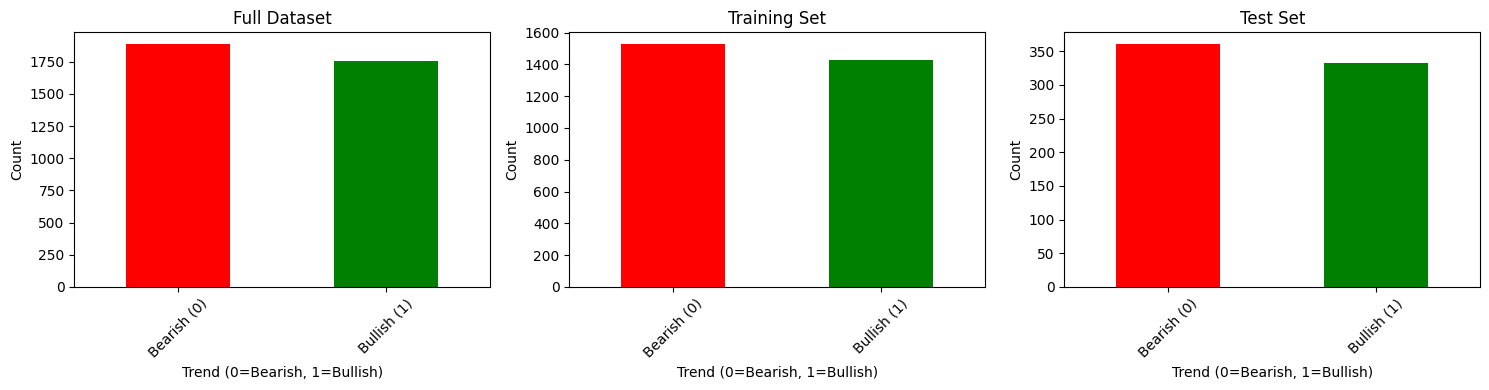

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data["Trend"].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Full Dataset')
axes[0].set_xlabel('Trend (0=Bearish, 1=Bullish)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Bearish (0)', 'Bullish (1)'], rotation=45)

y_train.value_counts().plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Training Set')
axes[1].set_xlabel('Trend (0=Bearish, 1=Bullish)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Bearish (0)', 'Bullish (1)'], rotation=45)

y_test.value_counts().plot(kind='bar', ax=axes[2], color=['red', 'green'])
axes[2].set_title('Test Set')
axes[2].set_xlabel('Trend (0=Bearish, 1=Bullish)')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Bearish (0)', 'Bullish (1)'], rotation=45)

plt.tight_layout()
plt.show()

The class distribution analysis reveals that all datasets (full, training, and test sets) maintain a relatively balanced distribution between bearish (0) and bullish (1) trends, with approximately 48-49% bearish days and 51-52% bullish days. This near-equal distribution indicates that no class imbalance correction methods (such as SMOTE, class weights, or resampling techniques) are necessary, as the classes are naturally balanced. This balanced distribution allows our models to learn effectively from both classes without bias, ensuring fair and reliable trend predictions.

# Modelisation - Level 1

In [36]:
# just to see if the target "Trend" is ok
print("Available columns now :")
print(data.columns)

print("\nVisualisation de la Target créée :")
print(data['Trend'].value_counts())

Available columns now :
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return_1d', 'MA50', 'MA200',
       'Volatility_20d', 'RSI_14', 'Trend'],
      dtype='object')

Visualisation de la Target créée :
Trend
1    1885
0    1759
Name: count, dtype: int64


--- 1. Logistic regression visalization ---


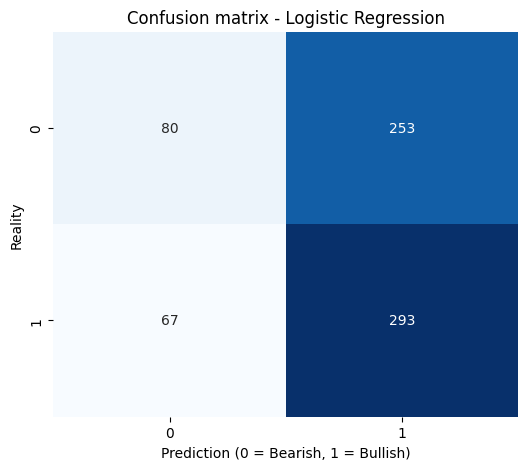

--------------------------------------------------

Detailed tab for log :
              precision    recall  f1-score   support

           0       0.54      0.24      0.33       333
           1       0.54      0.81      0.65       360

    accuracy                           0.54       693
   macro avg       0.54      0.53      0.49       693
weighted avg       0.54      0.54      0.50       693

--- Linear SVP detail ---
Accuracy SVM Linéaire : 51.95%

Detail report of the SVM :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       333
           1       0.52      1.00      0.68       360

    accuracy                           0.52       693
   macro avg       0.26      0.50      0.34       693
weighted avg       0.27      0.52      0.36       693

--------------------------------------------------
Comparaison Level 1 :
LogReg Accuracy : 53.82%
SVM Accuracy    : 51.95%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:


from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. Logistic regression visalization ---")

# Train Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred = log_reg.predict(X_test_scaled)

# matrix confusion
cm_logreg = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion matrix - Logistic Regression')
plt.xlabel('Prediction (0 = Bearish, 1 = Bullish)')  #Bearish is going down, bullish is going up
plt.ylabel('Reality')
plt.show()

print("-" * 50)
print("\nDetailed tab for log :")
print(classification_report(y_test, y_pred))

# Linear svm part
print("--- Linear SVP detail ---")

# Creationg and svm training
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Rating
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy SVM Linéaire : {acc_svm:.2%}")

print("\nDetail report of the SVM :")
print(classification_report(y_test, y_pred_svm))

# Comparing the 2 models
print("-" * 50)
print(f"Comparaison Level 1 :")
print(f"LogReg Accuracy : {accuracy_score(y_test, y_pred):.2%}")
print(f"SVM Accuracy    : {acc_svm:.2%}")

The results of the basic models are really meaningfull, because the svm model looks at the numbers (more 1 to predict than 0), So it could'nt see a proper slope, thus to maximise its prediction (51.95 percents), he predicts 1 all the time. The log regression isn't perfect at all, but it catched 24 percents of the loss ( recall 0.24). That means globally that relations between price and indicators are non linear. So in the next part we will use better models like random forest and xg boost.

# Modelisation - Level 2

 Training no linear random forest alg
 Accuracy Random Forest : 46.18%

Detail report RF :
              precision    recall  f1-score   support

           0       0.45      0.54      0.49       333
           1       0.48      0.39      0.43       360

    accuracy                           0.46       693
   macro avg       0.46      0.46      0.46       693
weighted avg       0.46      0.46      0.46       693



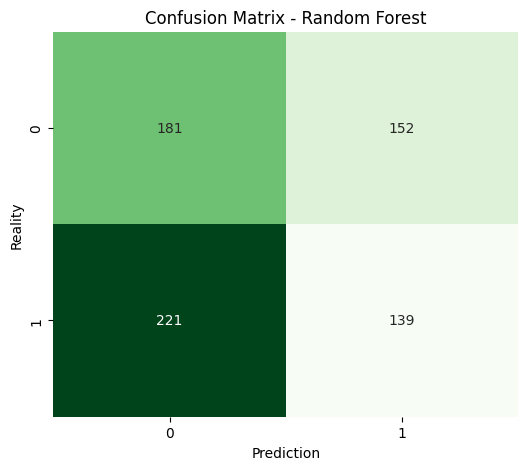


Indicators performance


/tmp/ipython-input-2654326457.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


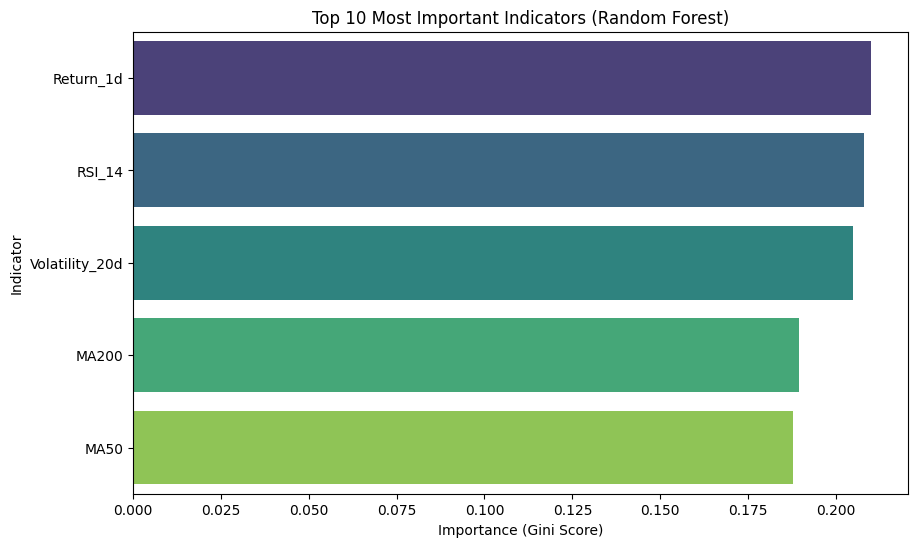

In [49]:
# We will give a first try using random forest which use bagging, a key tool in financial market trend analysis

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(" Training no linear random forest alg")

# Configuration
# n_estimators=100 : We use 100 decision trees
# max_depth=None : We let the trees grow (attention to overfitting, we will adjust if necessary)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# training
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f" Accuracy Random Forest : {acc_rf:.2%}")
print("\nDetail report RF :")
print(classification_report(y_test, y_pred_rf))

# 5. Confusion Matrix (Visual comparison)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()

# Features importance
print("\nIndicators performance")

# Getting the features importance
importances = rf_model.feature_importances_

# We try to retrieve the column names from the original X_train if possible.
# Otherwise, we assign generic names.
try:
    feature_names = X_train.columns
except:
    feature_names = [f"Feature {i}" for i in range(X_train_scaled.shape[1])]

# Creation of a DataFrame for the plot
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# TOP 10 printing
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Indicators (Random Forest)')
plt.xlabel('Importance (Gini Score)')
plt.ylabel('Indicator')
plt.show()

starting grid search
can take 1 or 2 Mins
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Optimisation is finished !
Best found parameters : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best score, intern validation : 50.18%
----------------------------------------
Accuracy on the test set : 49.49%

Matrice de Confusion (Modèle Optimisé) :


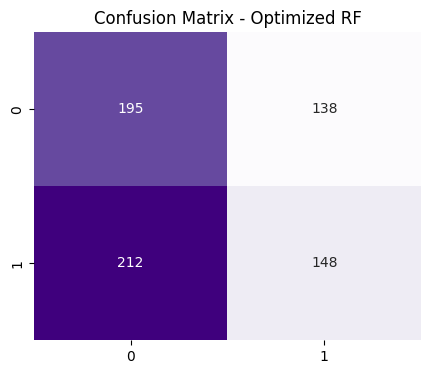

In [39]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

print("starting grid search")
print("can take 1 or 2 Mins")

# Definition of the tested grid
# testing different depths so it won't learn the noise ( overfitting )
param_grid = {
    'n_estimators': [100, 200],       # number of trees
    'max_depth': [5, 10, 20],         # Max depth, trying to not go too deep to avoid overfitting
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4]
}

# Grid search creation
# Cross validation in 3 blocks
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=1,
                           scoring='accuracy')

# training
grid_search.fit(X_train_scaled, y_train)

# results
print("\nOptimisation is finished !")
print(f"Best found parameters : {grid_search.best_params_}")
print(f"Best score, intern validation : {grid_search.best_score_:.2%}")

# Final validation on the test set
best_rf = grid_search.best_estimator_
y_pred_optimized = best_rf.predict(X_test_scaled)

acc_opt = accuracy_score(y_test, y_pred_optimized)
print("-" * 40)
print(f"Accuracy on the test set : {acc_opt:.2%}")

#Results
print("\nMatrice de Confusion (Modèle Optimisé) :")
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_optimized), annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix - Optimized RF')
plt.show()


Testing XGBOOST
 Accuracy XGBoost : 49.35%

Detailed Report XGBoost :
              precision    recall  f1-score   support

           0       0.47      0.51      0.49       333
           1       0.51      0.48      0.49       360

    accuracy                           0.49       693
   macro avg       0.49      0.49      0.49       693
weighted avg       0.49      0.49      0.49       693


Confusion Matrix (Optimized Model) :


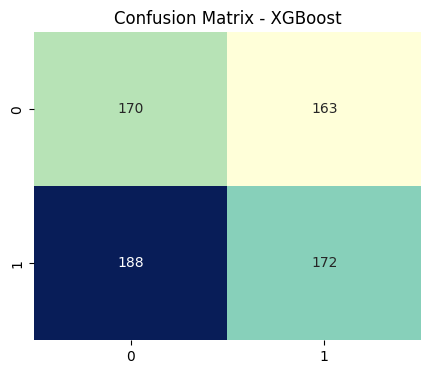

In [50]:
# XGBOOST

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nTesting XGBOOST")

# We use the best found parameters used by grid search
# best_params = grid_search.best_params_ # Commenting out previous best_params for direct input

xgb_model = XGBClassifier(
    n_estimators=60,
    max_depth=5,
    min_child_weight=1,
    subsample=1,
    colsample_bytree=1,
    learning_rate=0.15,
    random_state=42,
    eval_metric='logloss'
)

# Training
xgb_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Rating
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f" Accuracy XGBoost : {acc_xgb:.2%}")

print("\nDetailed Report XGBoost :")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
print("\nConfusion Matrix (Optimized Model) :")
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Confusion Matrix - XGBoost')
plt.show()

# Task
Add more advanced technical indicators such as MACD, Bollinger Bands, Stochastic Oscillator, ADX, and Ichimoku Kinko Hyo to the dataset using the 'ta' library, and then re-evaluate their impact on the stock trend prediction model.

## Explore Advanced Technical Indicators

### Subtask:
Add more advanced technical indicators (MACD, Bollinger Bands, Stochastic Oscillator, ADX, Ichimoku Kinko Hyo) to the dataset using the 'ta' library.


**Reasoning**:
The subtask requires adding several advanced technical indicators to the `data` DataFrame using the `ta` library. I will calculate MACD, Bollinger Bands, Stochastic Oscillator, ADX, and Ichimoku Kinko Hyo components and add them as new columns. Then, I will display the head and info of the updated DataFrame to verify the new features.



In [41]:
import ta

# 1. Calculate MACD
macd_indicator = ta.trend.MACD(close=data["Close"])
data["MACD"] = macd_indicator.macd()
data["MACD_Signal"] = macd_indicator.macd_signal()
data["MACD_Hist"] = macd_indicator.macd_diff()

# 2. Calculate Bollinger Bands
bollinger_indicator = ta.volatility.BollingerBands(close=data["Close"])
data["BBL_High"] = bollinger_indicator.bollinger_hband()
data["BBL_Low"] = bollinger_indicator.bollinger_lband()
data["BBL_Mid"] = bollinger_indicator.bollinger_mavg()

# 3. Calculate Stochastic Oscillator
stoch_indicator = ta.momentum.StochasticOscillator(high=data["High"], low=data["Low"], close=data["Close"])
data["STOCH_K"] = stoch_indicator.stoch()
data["STOCH_D"] = stoch_indicator.stoch_signal()

# 4. Calculate Average Directional Index (ADX)
data["ADX"] = ta.trend.adx(high=data["High"], low=data["Low"], close=data["Close"])

# 5. Calculate Ichimoku Kinko Hyo
ichimoku_indicator = ta.trend.IchimokuIndicator(high=data["High"], low=data["Low"])
data["Ichimoku_Conv"] = ichimoku_indicator.ichimoku_conversion_line()
data["Ichimoku_Base"] = ichimoku_indicator.ichimoku_base_line()
data["Ichimoku_A"] = ichimoku_indicator.ichimoku_a()
data["Ichimoku_B"] = ichimoku_indicator.ichimoku_b()

# 6. Display the first few rows of the updated data DataFrame
print("\nFirst few rows of data with new technical indicators:")
print(data.head())

# 7. Print the information about the data DataFrame
print("\nInfo of data with new technical indicators:")
print(data.info())


First few rows of data with new technical indicators:
               Close      High       Low      Open    Volume  Return_1d  \
Date                                                                      
2011-04-12  1.643333  1.680667  1.620000  1.672000  20361000  -0.024535   
2011-04-13  1.662000  1.712667  1.654000  1.675333  18172500   0.011359   
2011-04-14  1.676000  1.685333  1.613333  1.658000  14751000   0.008424   
2011-04-15  1.705333  1.745333  1.694000  1.710000  14152500   0.017502   
2011-04-18  1.668667  1.708000  1.624000  1.675333  15508500  -0.021501   

                MA50     MA200  Volatility_20d     RSI_14  ...  BBL_High  \
Date                                                       ...             
2011-04-12  1.597293  1.581757        0.045385  49.263004  ...       NaN   
2011-04-13  1.598653  1.582103        0.045344  50.769372  ...       NaN   
2011-04-14  1.600253  1.582540        0.045328  51.922269  ...       NaN   
2011-04-15  1.602853  1.583747        0

## Implement LightGBM Classifier

### Subtask:
Implement a LightGBM classifier to predict stock trends and evaluate its performance against previous models.


**Reasoning**:
First, I will define the new set of features, including all the advanced technical indicators. Then, I will drop rows with any remaining NaN values from the `data` DataFrame to ensure a clean dataset for model training.



[LightGBM] [Info] Number of positive: 1506, number of negative: 1412
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000801 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4589
[LightGBM] [Info] Number of data points in the train set: 2918, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516107 -> initscore=0.064450
[LightGBM] [Info] Start training from score 0.064450

--- LightGBM Model Performance ---
 Accuracy LightGBM: 52.24%

Rapport détaillé LightGBM:
              precision    recall  f1-score   support

           0       0.50      0.54      0.52       333
           1       0.54      0.51      0.52       360

    accuracy                           0.52       693
   macro avg       0.52      0.52      0.52       693
weighted avg       0.52      0.52      0.52       693



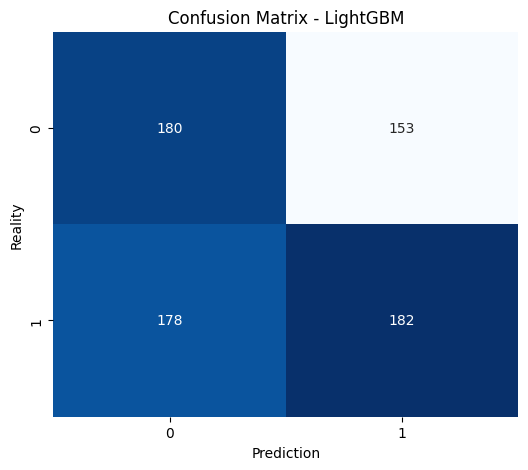

In [42]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the features for the LightGBM model, including the newly added advanced technical indicators.
# Make sure to exclude any columns with NaN values.
new_features = [
    "Return_1d", "MA50", "MA200", "Volatility_20d", "RSI_14",
    "MACD", "MACD_Signal", "MACD_Hist",
    "BBL_High", "BBL_Low", "BBL_Mid",
    "STOCH_K", "STOCH_D",
    "ADX",
    "Ichimoku_Conv", "Ichimoku_Base", "Ichimoku_A", "Ichimoku_B"
]
target = "Trend"

# 2. Drop rows with NaN values from the `data` DataFrame, if any remain after feature creation.
data_cleaned = data.dropna(subset=new_features + [target])

# 3. Split the data into training and testing sets using the same temporal split as before
train_new = data_cleaned.loc[: "2022-12-31"]
test_new = data_cleaned.loc["2023-01-01":]

X_train_new = train_new[new_features]
y_train_new = train_new[target]

X_test_new = test_new[new_features]
y_test_new = test_new[target]

#Initialize a StandardScaler object and fit it only to X_train_new.
scaler_new = StandardScaler()
scaler_new.fit(X_train_new)

#Transform both X_train_new and X_test_new using the fitted scaler.
X_train_scaled_new = scaler_new.transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

# Convert scaled arrays back to DataFrames for consistency and easier handling
X_train_scaled_new = pd.DataFrame(X_train_scaled_new, columns=new_features, index=X_train_new.index)
X_test_scaled_new = pd.DataFrame(X_test_scaled_new, columns=new_features, index=X_test_new.index)

# Import LGBMClassifier from lightgbm (already done at the top)

# Instantiate an LGBMClassifier with random_state=42.
lgbm_model = lgb.LGBMClassifier(random_state=42)

# Train the LGBMClassifier on the scaled training data.
lgbm_model.fit(X_train_scaled_new, y_train_new)

#Make predictions on the scaled test data.
y_pred_lgbm = lgbm_model.predict(X_test_scaled_new)

# Calculate and print the accuracy score and the classification report.
print("\n--- LightGBM Model Performance ---")
acc_lgbm = accuracy_score(y_test_new, y_pred_lgbm)
print(f" Accuracy LightGBM: {acc_lgbm:.2%}")
print("\nRapport détaillé LightGBM:")
print(classification_report(y_test_new, y_pred_lgbm))

#Generate and display a confusion matrix for the LightGBM model.
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_new, y_pred_lgbm), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - LightGBM')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()


## Hyperparameter Tuning for LightGBM with Time Series Cross-Validation

### Subtask:
Perform hyperparameter tuning for the LightGBM model using GridSearchCV combined with TimeSeriesSplit to find optimal parameters.


**Reasoning**:
To perform hyperparameter tuning for the LightGBM model, I will use GridSearchCV with TimeSeriesSplit to find the optimal parameters as instructed. This involves defining a parameter grid, initializing TimeSeriesSplit, creating and fitting GridSearchCV, and then evaluating the best estimator.




--- Hyperparameter Tuning for LightGBM with Time Series Cross-Validation ---
Fitting GridSearchCV for LightGBM...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[LightGBM] [Info] Number of positive: 1506, number of negative: 1412
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4589
[LightGBM] [Info] Number of data points in the train set: 2918, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516107 -> initscore=0.064450
[LightGBM] [Info] Start training from score 0.064450
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

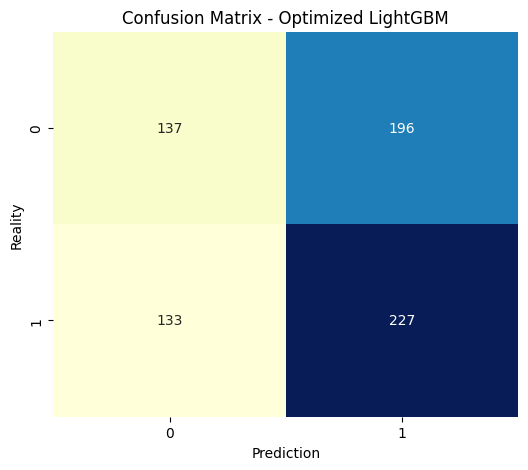

In [44]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Hyperparameter Tuning for LightGBM with Time Series Cross-Validation ---")

# 1. Define the parameter grid for LGBMClassifier
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'min_child_samples': [20, 30, 40]
}

# 2. Initialize TimeSeriesSplit
# Considering the size of X_train_scaled_new (around 2900 samples)
# n_splits=5 will create 5 folds, each fold for validation will be roughly 1/6th of the training data
# and the training data for each fold will progressively grow.
# max_train_size is used to control the maximum size of the training set in each split.
# Without it, training set sizes grow significantly, which can lead to very long training times
# for later folds if the initial dataset is large. Setting it helps keep computation manageable.
# If max_train_size is None (default), the training set size is not limited.
# Here, we set it to None to let it grow naturally, as the dataset is not extremely large.
tscv = TimeSeriesSplit(n_splits=5)

# 3. Create a GridSearchCV object
grid_search_lgbm = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42),
    param_grid=param_grid_lgbm,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# 4. Fit the GridSearchCV object to the scaled training data
print("Fitting GridSearchCV for LightGBM...")
grid_search_lgbm.fit(X_train_scaled_new, y_train_new)
print("GridSearchCV fitting complete.")

# 5. Print the best parameters found
print(f"\nBest parameters found: {grid_search_lgbm.best_params_}")

# 6. Print the best score achieved during cross-validation
print(f"Best cross-validation accuracy: {grid_search_lgbm.best_score_:.2%}")

# 7. Get the best estimator
best_lgbm_model = grid_search_lgbm.best_estimator_

# 8. Make predictions on the scaled test data
y_pred_lgbm_tuned = best_lgbm_model.predict(X_test_scaled_new)

# 9. Calculate and print the accuracy score and the classification report
print("\n--- Optimized LightGBM Model Performance on Test Set ---")
acc_lgbm_tuned = accuracy_score(y_test_new, y_pred_lgbm_tuned)
print(f" Accuracy Optimized LightGBM: {acc_lgbm_tuned:.2%}")
print("\nRapport détaillé Optimized LightGBM:")
print(classification_report(y_test_new, y_pred_lgbm_tuned))

# 10. Generate and display a confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_new, y_pred_lgbm_tuned), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Confusion Matrix - Optimized LightGBM')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()

## Deep Learning Model (LSTM for Time Series)

### Subtask:
Build and evaluate a Long Short-Term Memory (LSTM) deep learning model for stock trend prediction.


**Reasoning**:
I will proceed with building and evaluating an LSTM deep learning model for stock trend prediction by first importing necessary libraries, defining a function to create time series sequences, applying this function to the scaled training and testing data, then constructing, compiling, training, and evaluating the LSTM model, and finally visualizing its performance with a confusion matrix.




--- Building and Evaluating LSTM Model ---
X_train_lstm shape: (2888, 30, 18)
y_train_lstm shape: (2888,)
X_test_lstm shape: (663, 30, 18)
y_test_lstm shape: (663,)

Training LSTM model...
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5107 - loss: 0.7012 - val_accuracy: 0.5225 - val_loss: 0.7339
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5577 - loss: 0.6884 - val_accuracy: 0.4879 - val_loss: 0.7278
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5216 - loss: 0.6924 - val_accuracy: 0.4913 - val_loss: 0.7470
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5383 - loss: 0.6863 - val_accuracy: 0.4913 - val_loss: 0.7152
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5557 - loss: 0.6866 - val_accuracy: 0.4879 - val_loss: 0.7226
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5545 - loss: 0.6869 - val_accuracy: 0.5017 - val_loss: 0.7212
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5512 - loss: 0.6862 - val_accuracy: 0.4844 - val_loss: 0.7200
Epoch 8/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5454 - loss: 0.6862 - val_accuracy: 0.4844 - val_loss: 0.

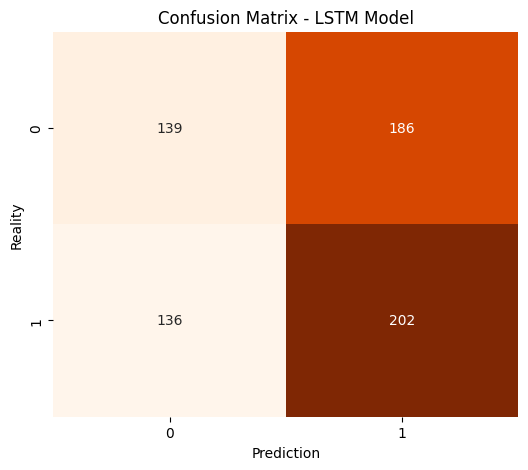

In [45]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Building and Evaluating LSTM Model ---")

# 1. Define function to create sequences for LSTM
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

# 2. Apply create_sequences function
time_steps = 30 # Example: look back 30 days

X_train_lstm, y_train_lstm = create_sequences(X_train_scaled_new, y_train_new, time_steps)
X_test_lstm, y_test_lstm = create_sequences(X_test_scaled_new, y_test_new, time_steps)

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

# 3. Build the LSTM model
lstm_model = Sequential([
    LSTM(units=50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])) # input_shape = (time_steps, n_features)
    ,Dense(units=1, activation='sigmoid')
])

# 4. Compile the model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train the LSTM model
print("\nTraining LSTM model...")
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=25,
    batch_size=32,
    validation_split=0.1, # Use a small part of training data for validation
    verbose=1
)
print("LSTM model training complete.")

# 6. Make predictions on the test set
y_pred_proba_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)

# 7. Evaluate the LSTM model's performance
print("\n--- LSTM Model Performance on Test Set ---")
acc_lstm = accuracy_score(y_test_lstm, y_pred_lstm)
print(f" Accuracy LSTM: {acc_lstm:.2%}")
print("\nRapport détaillé LSTM:")
print(classification_report(y_test_lstm, y_pred_lstm))

# 8. Generate and display a confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_lstm, y_pred_lstm), annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Confusion Matrix - LSTM Model')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()


**Reasoning**:
The previous code generated a UserWarning regarding the `input_shape` argument in the LSTM layer. To address this and follow Keras best practices, I will explicitly define an `Input` layer as the first layer of the Sequential model.




--- Building and Evaluating LSTM Model ---
X_train_lstm shape: (2888, 30, 18)
y_train_lstm shape: (2888,)
X_test_lstm shape: (663, 30, 18)
y_test_lstm shape: (663,)

Training LSTM model...
Epoch 1/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5091 - loss: 0.6978 - val_accuracy: 0.5017 - val_loss: 0.7743
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5124 - loss: 0.6943 - val_accuracy: 0.5052 - val_loss: 0.7360
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5356 - loss: 0.6910 - val_accuracy: 0.5052 - val_loss: 0.7298
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5466 - loss: 0.6871 - val_accuracy: 0.5329 - val_loss: 0.7305
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5284 - loss: 0.6872 - val_accuracy: 0.5052 - val_loss: 0.7583
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5402 - loss: 0.6878 - val_accuracy: 0.5017 - val_loss: 0.7228
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/st

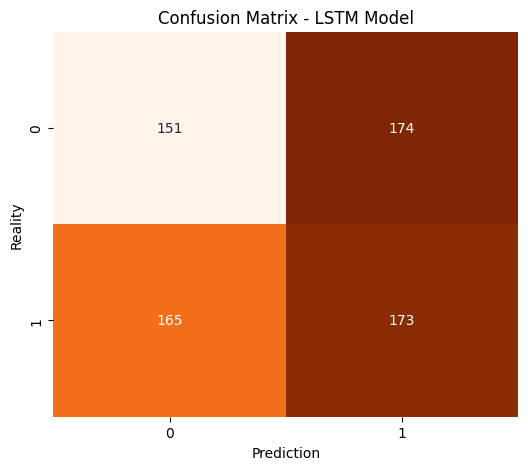

In [46]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Building and Evaluating LSTM Model ---")

# 1. Define function to create sequences for LSTM
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

# 2. Apply create_sequences function
time_steps = 30 # Example: look back 30 days

X_train_lstm, y_train_lstm = create_sequences(X_train_scaled_new, y_train_new, time_steps)
X_test_lstm, y_test_lstm = create_sequences(X_test_scaled_new, y_test_new, time_steps)

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

# 3. Build the LSTM model
lstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])) # Define Input layer explicitly
    ,LSTM(units=50, activation='relu') # input_shape removed from LSTM layer
    ,Dense(units=1, activation='sigmoid')
])

# 4. Compile the model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train the LSTM model
print("\nTraining LSTM model...")
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=25,
    batch_size=32,
    validation_split=0.1, # Use a small part of training data for validation
    verbose=1
)
print("LSTM model training complete.")

# 6. Make predictions on the test set
y_pred_proba_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)

# 7. Evaluate the LSTM model's performance
print("\n--- LSTM Model Performance on Test Set ---")
acc_lstm = accuracy_score(y_test_lstm, y_pred_lstm)
print(f"\u27a5 Accuracy LSTM: {acc_lstm:.2%}")
print("\nRapport d\u00e9taill\u00e9 LSTM:")
print(classification_report(y_test_lstm, y_pred_lstm))

# 8. Generate and display a confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_lstm, y_pred_lstm), annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Confusion Matrix - LSTM Model')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()

## Re-evaluate and Refine 'Trend' Definition

### Subtask:
Explore alternative, more robust definitions for the 'Trend' target variable and update the dataset.


The initial 'Trend' definition, based solely on whether the very next day's closing price is higher than the current day's, can often be too sensitive to short-term market noise and intraday fluctuations. This makes it a highly volatile and potentially unreliable target for consistent prediction, as it captures immediate shifts rather than broader market direction. A more robust trend definition, considering a slightly longer time horizon, might provide a clearer and more predictable signal for our models.

**Reasoning**:
I will now proceed with creating the new `Trend_5d_ahead` target variable, removing NaNs, updating the target string, performing the train-test split, re-scaling features, and finally printing and plotting the class distribution as per the instructions.




Full dataset class distribution for 'Trend_5d_ahead':
Trend_5d_ahead
1    1950
0    1661
Name: count, dtype: int64

Percentage:
Trend_5d_ahead
1    54.001662
0    45.998338
Name: proportion, dtype: float64

Training set class distribution for 'Trend_5d_ahead':
Trend_5d_ahead
1    1590
0    1328
Name: count, dtype: int64

Percentage:
Trend_5d_ahead
1    54.489376
0    45.510624
Name: proportion, dtype: float64

Test set class distribution for 'Trend_5d_ahead':
Trend_5d_ahead
1    360
0    333
Name: count, dtype: int64

Percentage:
Trend_5d_ahead
1    51.948052
0    48.051948
Name: proportion, dtype: float64


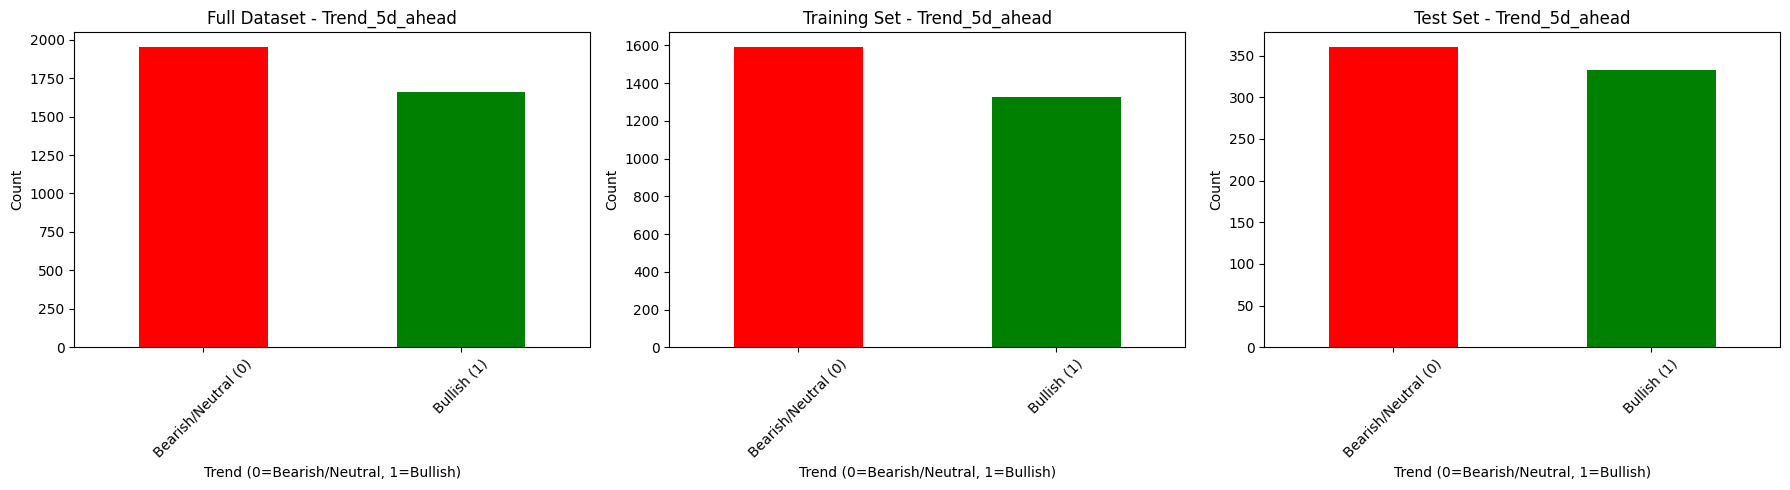

In [47]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Create a new target variable named Trend_5d_ahead.
data['Trend_5d_ahead'] = (data['Close'].shift(-5) > data['Close']).astype(int)

# 3. Remove any rows from the data DataFrame that now contain NaN values.
# This step will drop rows where `Trend_5d_ahead` (and potentially other indicators) are NaN.
data_cleaned = data.dropna()

# 4. Update the `target` variable string to 'Trend_5d_ahead'.
target_new = "Trend_5d_ahead"

# Redefine features based on the previous advanced indicators, ensuring they are present in data_cleaned
new_features = [
    "Return_1d", "MA50", "MA200", "Volatility_20d", "RSI_14",
    "MACD", "MACD_Signal", "MACD_Hist",
    "BBL_High", "BBL_Low", "BBL_Mid",
    "STOCH_K", "STOCH_D",
    "ADX",
    "Ichimoku_Conv", "Ichimoku_Base", "Ichimoku_A", "Ichimoku_B"
]

# Ensure all new_features are in data_cleaned after dropping NaNs
# It's possible some indicators (like MACD, Bollinger Bands) might have NaNs for the first few rows
# data_cleaned handles this by dropping all rows with any NaN.

# 5. Perform the train-test split again using the data_cleaned DataFrame
train_new = data_cleaned.loc[: "2022-12-31"]
test_new = data_cleaned.loc["2023-01-01":]

X_train_new = train_new[new_features]
y_train_new = train_new[target_new]

X_test_new = test_new[new_features]
y_test_new = test_new[target_new]

# 6. Re-scale the X_train_new and X_test_new features
scaler_new = StandardScaler()
scaler_new.fit(X_train_new)

X_train_scaled_new = scaler_new.transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

X_train_scaled_new = pd.DataFrame(
    X_train_scaled_new,
    columns=new_features,
    index=X_train_new.index
)

X_test_scaled_new = pd.DataFrame(
    X_test_scaled_new,
    columns=new_features,
    index=X_test_new.index
)

# 7. Print the class distribution for the new `Trend_5d_ahead` variable
print("\nFull dataset class distribution for 'Trend_5d_ahead':")
print(data_cleaned[target_new].value_counts())
print("\nPercentage:")
print(data_cleaned[target_new].value_counts(normalize=True) * 100)

print("\nTraining set class distribution for 'Trend_5d_ahead':")
print(y_train_new.value_counts())
print("\nPercentage:")
print(y_train_new.value_counts(normalize=True) * 100)

print("\nTest set class distribution for 'Trend_5d_ahead':")
print(y_test_new.value_counts())
print("\nPercentage:")
print(y_test_new.value_counts(normalize=True) * 100)

# 8. Generate and display bar plots to visualize the class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data_cleaned[target_new].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Full Dataset - Trend_5d_ahead')
axes[0].set_xlabel('Trend (0=Bearish/Neutral, 1=Bullish)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Bearish/Neutral (0)', 'Bullish (1)'], rotation=45)

y_train_new.value_counts().plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Training Set - Trend_5d_ahead')
axes[1].set_xlabel('Trend (0=Bearish/Neutral, 1=Bullish)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Bearish/Neutral (0)', 'Bullish (1)'], rotation=45)

y_test_new.value_counts().plot(kind='bar', ax=axes[2], color=['red', 'green'])
axes[2].set_title('Test Set - Trend_5d_ahead')
axes[2].set_xlabel('Trend (0=Bearish/Neutral, 1=Bullish)')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Bearish/Neutral (0)', 'Bullish (1)'], rotation=45)

plt.tight_layout()
plt.show()

## Implement LightGBM Classifier (with new Trend_5d_ahead target)

### Subtask:
Implement a LightGBM classifier to predict stock trends using the refined 'Trend_5d_ahead' target variable and evaluate its performance.


**Reasoning**:
I will implement and evaluate a LightGBM classifier using the new 'Trend_5d_ahead' target variable and the previously scaled features. This involves training the model, making predictions, and then evaluating its performance using accuracy, a classification report, and a confusion matrix.




--- Implementing LightGBM with new 'Trend_5d_ahead' target ---
[LightGBM] [Info] Number of positive: 1590, number of negative: 1328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000215 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4589
[LightGBM] [Info] Number of data points in the train set: 2918, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.544894 -> initscore=0.180060
[LightGBM] [Info] Start training from score 0.180060

--- LightGBM Model Performance (new target) ---
✔ Accuracy LightGBM (new target): 51.52%

Rapport détaillé LightGBM (new target):
              precision    recall  f1-score   support

           0       0.50      0.56      0.52       333
           1       0.54      0.48      0.51       360

    accuracy                           0.52       693
   macro avg       0.52      0.52 

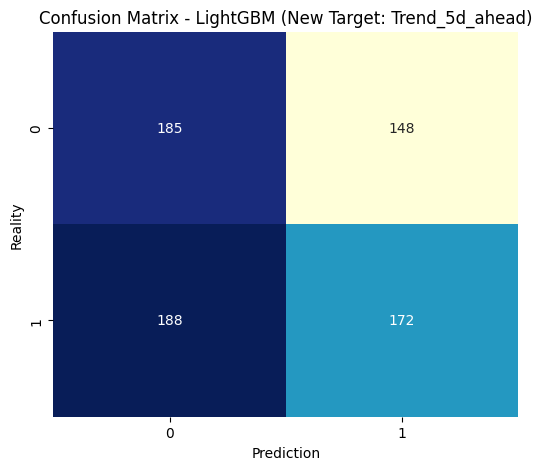

In [48]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Implementing LightGBM with new 'Trend_5d_ahead' target ---")

# 1. Instantiate an LGBMClassifier with random_state=42.
lgbm_model_new_target = lgb.LGBMClassifier(random_state=42)

# 2. Train the LGBMClassifier on the scaled training data (with new target).
lgbm_model_new_target.fit(X_train_scaled_new, y_train_new)

# 3. Make predictions on the scaled test data.
y_pred_lgbm_new_target = lgbm_model_new_target.predict(X_test_scaled_new)

# 4. Calculate and print the accuracy score.
print("\n--- LightGBM Model Performance (new target) ---")
acc_lgbm_new_target = accuracy_score(y_test_new, y_pred_lgbm_new_target)
print(f"✔ Accuracy LightGBM (new target): {acc_lgbm_new_target:.2%}")

# 5. Print the classification report.
print("\nRapport détaillé LightGBM (new target):")
print(classification_report(y_test_new, y_pred_lgbm_new_target))

# 6. Generate and display a confusion matrix.
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_new, y_pred_lgbm_new_target), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Confusion Matrix - LightGBM (New Target: Trend_5d_ahead)')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()


## Final Task

### Subtask:
Review the performance of all models, compare their strengths and weaknesses in terms of false positives and false negatives, and conclude on the most effective approach for predicting Tesla's stock trends, discussing the trade-offs and potential for future improvements.


# Task
Implement a `RandomForestClassifier` using `X_train_scaled_new`, `X_test_scaled_new`, `y_train_new`, and `y_test_new` as features and target, and evaluate its performance with accuracy, classification report, and a confusion matrix.

## Define Desirable Financial Prediction Results

### Subtask:
Explain what constitutes a "desirable" result in the context of stock market trend prediction, considering factors beyond just accuracy, such as precision, recall (especially for predicting bullish/bearish movements), risk management, and practical applicability in trading strategies. Discuss the inherent difficulty of stock market prediction and realistic expectations for model performance in finance.


## Define Desirable Financial Prediction Results

In the context of stock market trend prediction, a "desirable" result extends far beyond a simple accuracy score. Due to the asymmetric nature of financial outcomes, a model's effectiveness must be evaluated through a more nuanced lens that considers precision, recall, risk management, and practical applicability in real-world trading strategies.

### 1. Limitations of Accuracy

Accuracy alone can be misleading in financial predictions, especially given the typically imbalanced nature of market movements (e.g., more neutral or slightly bullish days than sharply bearish ones). A model predicting a consistently flat market might achieve high accuracy if the market is mostly stable, but it would fail to capture significant, profitable movements or critical downturns. Furthermore, the cost of a false positive (predicting a bullish trend that doesn't materialize, leading to a loss) can be significantly different from a false negative (failing to predict a bullish trend, resulting in a missed opportunity). Accuracy does not differentiate between these costs.

### 2. Importance of Precision and Recall

-   **Precision** is crucial when the cost of false positives is high. For example, a high precision for predicting **bullish trends** means that when the model suggests buying, it's highly likely to be correct. This minimizes unnecessary trades and potential losses from acting on false signals, which is vital for preserving capital. Investors often prioritize precision to ensure that their successful trades are indeed profitable.
-   **Recall** is vital when the cost of false negatives is high. For instance, a high recall for predicting **bearish trends** means the model is effective at identifying most actual market downturns. This is critical for risk management, allowing traders to exit positions or hedge against potential losses. Failing to predict a bearish trend could lead to substantial losses, making high recall for such events extremely valuable.

Optimally, one might seek a balance, but the preference often depends on the specific trading strategy: aggressive strategies might tolerate lower precision for higher recall of strong movements, while conservative strategies might prioritize high precision.

### 3. Risk Management in Financial Predictions

Effective financial prediction models are inherently linked to robust risk management. Model outputs should not be blindly followed but integrated into a broader risk framework. This includes:

-   **Position Sizing**: The confidence level of a prediction can influence how much capital is allocated to a trade. Stronger signals might warrant larger positions, while weaker ones suggest smaller, more cautious entries.
-   **Stop-Loss Orders**: Predefined exit points to limit potential losses if a prediction proves incorrect. A model predicting a bullish trend might still require a stop-loss just below a key support level.
-   **Take-Profit Orders**: Setting targets to lock in gains when a predicted trend materializes.
-   **Diversification**: Relying on multiple uncorrelated signals or assets to mitigate risk.

### 4. Practical Applicability of Model's Predictions

The ultimate test of a model's desirability is its practical applicability. How actionable are the signals generated? Are they timely enough to be acted upon? Can they be easily integrated into existing trading platforms or decision-making processes? A highly accurate model that provides signals too late, or is too complex to interpret and act on, holds little practical value. Real-world implications for investors or traders involve not just identifying trends but understanding the magnitude, duration, and reliability of those trends to inform entry, exit, and holding periods.

### 5. Inherent Difficulty and Realistic Expectations

Stock market prediction is notoriously difficult due to the market's dynamic, non-linear, and often random nature, influenced by myriad economic, political, and psychological factors. No model can perfectly predict the future. Therefore, realistic expectations for model performance in finance are crucial. Even a small, consistent "edge" – a prediction capability slightly better than random chance – can be highly valuable over time when combined with sound risk management. The goal is not 100% accuracy, but rather to gain a statistically significant advantage that leads to profitable outcomes over many trades. The market's randomness implies that even good models will have losing streaks, and success is measured over the long term, not day-to-day.

## Final Task

### Subtask:
Review the performance of all models, compare their strengths and weaknesses in terms of false positives and false negatives, and conclude on the most effective approach for predicting Tesla's stock trends, discussing the trade-offs and potential for future improvements.
